# NB13 — 배송 운영효과 비교 분석
**관측 수요·기상·공간경로 기반 배송 운영효과 비교 분석**

드론+로봇 배송 vs 오토바이 기준선을 비교하여 성남시 드론 배송 시스템의 정량적 효과를 도출합니다.

| 입력 | 출처 |
|------|------|
| `nb12_hub_service_assignments.csv` | NB12 최종 허브 배정 (67개 경로) |
| `nb12_final_hubs.csv` | NB12 최종 5개 허브 |
| `nb11_route_pairs.csv` | NB11 경로 타당성 지표 |
| `demand_grid.csv` | 수요 격자 좌표·ADM |
| `card_hourly_demand.parquet` | 시간대별 카드 수요 비율 |
| `weather_observed_summary.json` | KMA 2025 관측 기상 요약 |
| `배달상권.shp` | 소상공인365 배달상권 (CRS=EPSG:5185) |

**9개 출력 파일:** `nb13_route_comparison.csv` · `nb13_hub_summary.csv` · `nb13_hourly_breakdown.csv`
· `nb13_district_summary.csv` · `nb13_kosha_cache.csv` · `nb13_gg_speed_ref.csv`
· `nb13_delivery_impact_map.html` · `nb13_comparison_chart.png` · `nb13_summary_report.json`

In [1]:
# ── §2 하드 게이트 ────────────────────────────────────────────────────────
# NB13 requires NB12 outputs. Fail immediately if missing or wrong row count.
import os, sys
from pathlib import Path
import pandas as pd

BASE      = Path('C:/Users/jimin/Desktop/1_BITAmin_16기/1_Seongnam_reset')
PROCESSED = BASE / 'processed'

NB12_REQUIRED = [
    PROCESSED / 'nb12_hub_service_assignments.csv',
    PROCESSED / 'nb12_final_hubs.csv',
]

missing = [str(f) for f in NB12_REQUIRED if not f.exists()]
if missing:
    raise FileNotFoundError(
        'Run NB12_final_hub_selection.ipynb first.\n'
        + '\n'.join(f'  MISSING: {m}' for m in missing)
    )

# Row-count guard — verify NB12 produced a non-empty assignment table
_chk = pd.read_csv(PROCESSED / 'nb12_hub_service_assignments.csv')
if len(_chk) == 0:
    raise ValueError('nb12_hub_service_assignments.csv is empty. Re-run NB12.')
# Cross-join sanity: assignments should not exceed total route pairs
_nb12_hubs = pd.read_csv(PROCESSED / 'nb12_final_hubs.csv')
_expected_hubs = len(_nb12_hubs)
_actual_hubs = _chk['assigned_lot_id'].nunique() if 'assigned_lot_id' in _chk.columns else None
print(f'✅ Hard gate passed: {len(_chk)} assigned routes, {_expected_hubs} hubs confirmed.')
del _chk, _nb12_hubs

✅ Hard gate passed: 77 assigned routes, 6 hubs confirmed.


In [2]:
# ── §3 환경 설정 ──────────────────────────────────────────────────────────
import os, re, json, time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

DATA      = BASE / 'processed'
OUT11     = BASE / 'processed'
OUT13     = BASE / 'processed'

# Correct endpoints and keys. Do not print raw keys in output.
KOSHA_ENDPOINT = 'https://apis.data.go.kr/B552468/DlvrTime/gettime'
KOSHA_API_KEY  = os.getenv(
    'KOSHA_API_KEY',
    '7f8caa42fc44f47c473d5fcdf799ee3cea766741b324a9f147fedad08e64ede7'
)
GG_SPEED_URL = 'https://openapi.gg.go.kr/ORDNTMSPEED'
GG_API_KEY   = os.getenv(
    'GG_API_KEY',
    'df2bd0dcf8424a9d85c38405c797ad91'
)

KOSHA_CACHE = OUT13 / 'nb13_kosha_cache.csv'
GG_CACHE    = OUT13 / 'nb13_traffic_speed_reference.csv'
GG_CACHE_ALIAS = OUT13 / 'nb13_gg_speed_ref.csv'

P_DRONE_WX_AVAILABLE = 0.944093

# Operating assumptions.
TAKEOFF_MIN = 1.0
LANDING_MIN = 1.0
HUB_HANDOFF_MIN = 1.5
ROBOT_HANDOFF_MIN = 1.0
MOTO_PICKUP_DROPOFF_OVERHEAD_MIN = 4.0
MOTORCYCLE_AVG_SPEED = 25.0
MOTORCYCLE_PEAK_SPEED = 18.0
DETOUR_FACTOR = 1.35

# Emission factors, same family as old NB14 but in gCO2/km.
MOTO_CO2_G_KM  = 144.5
DRONE_CO2_G_KM = 21.0
ROBOT_CO2_G_KM = 7.9

print('§3 Config ready.')
print(f'  BASE      : {BASE}')
print(f'  DATA/OUT  : {DATA}')
print(f'  KOSHA_CACHE: {KOSHA_CACHE}')
print(f'  GG_CACHE  : {GG_CACHE}')


§3 Config ready.
  BASE      : C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset
  DATA/OUT  : C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed
  KOSHA_CACHE: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_kosha_cache.csv
  GG_CACHE  : C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_traffic_speed_reference.csv


In [3]:
# ── §4 입력 데이터 로드 ───────────────────────────────────────────────────
import geopandas as gpd
import json, re

# 4-a  NB12 outputs  (all files live in BASE/processed/)
df_assign = pd.read_csv(DATA / 'nb12_hub_service_assignments.csv')
df_hubs   = pd.read_csv(DATA / 'nb12_final_hubs.csv')

# 4-b  Hub coordinates — nb12_final_hubs.csv has NO lat/lon; join from candidate sites
sites_csv = DATA / 'final_candidate_sites.csv'
if sites_csv.exists():
    df_sites = pd.read_csv(sites_csv)
else:
    gdf_s = gpd.read_file(DATA / 'final_candidate_sites.gpkg',
                          layer='final_candidate_sites')
    df_sites = pd.DataFrame({'lot_id': gdf_s['lot_id'],
                              'lat': gdf_s.geometry.y,
                              'lon': gdf_s.geometry.x})
hub_coords = (df_sites[['lot_id', 'lat', 'lon']]
              .rename(columns={'lat': 'hub_lat', 'lon': 'hub_lon'}))
df_hubs = df_hubs.merge(hub_coords, on='lot_id', how='left')
hub_null = df_hubs[['hub_lat', 'hub_lon']].isna().any(axis=1).sum()
assert hub_null == 0, f'{hub_null} hub(s) missing lat/lon after joining candidate sites'

# 4-c  Target zone coordinates — from demand_grid.csv
df_demand   = pd.read_csv(DATA / 'demand_grid.csv')
zone_coords = (df_demand[['h3_index', 'lat', 'lon', 'CSV_ADMI_CD']]
               .rename(columns={'h3_index': 'target_h3_index',
                                'lat': 'target_lat',
                                'lon': 'target_lon'}))

# 4-d  NB11 route pairs
df_routes = pd.read_csv(DATA / 'nb11_route_pairs.csv')
# key cols: lot_id, target_h3_index, drone_time_min, robot_distance_m,
#           robot_time_min_adjusted, mean_slope_deg, route_mean_constraint_score

# 4-e  Hourly card demand weights
df_hourly = pd.read_parquet(DATA / 'card_hourly_demand.parquet')
# cols: admi_cty_no (Int64), hour_code, hour_label, hour_ratio,
#       is_lunch_peak, is_dinner_peak, is_late_night

# 4-f  Population flow (supplementary, optional)
try:
    df_flow = pd.read_parquet(DATA / 'flow_pop_hourly.parquet')
    print(f'  flow_pop_hourly: {len(df_flow)} rows')
except FileNotFoundError:
    df_flow = None
    print('  flow_pop_hourly: not found (skipped)')

# 4-g  Weather observed summary  — must open as UTF-8
wx_path = DATA / 'weather_observed_summary.json'
with open(wx_path, encoding='utf-8') as _f:
    wx_summary = json.load(_f)
P_DRONE_WX_AVAILABLE = wx_summary.get('P_drone_weather_available', P_DRONE_WX_AVAILABLE)
print(f'  P_drone_weather_available = {P_DRONE_WX_AVAILABLE:.6f}')

# 4-h  소상공인365 배달상권 shapefile
# Actual location under 00_data/소상공인시장진흥공단_소상공인365_배달상권_20250831/배달상권/
# CRS is NOT 5179 — actual coords (x≈209k, y≈426-431k) prove it is EPSG:5185
shp_path = (BASE / '00_data'
            / '소상공인시장진흥공단_소상공인365_배달상권_20250831'
            / '배달상권' / '배달상권.shp')
if not shp_path.exists():
    # Fallback: scan 00_data recursively for 배달상권.shp
    hits = list((BASE / '00_data').rglob('배달상권.shp'))
    shp_path = hits[0] if hits else None

if shp_path and shp_path.exists():
    gdf_baedal = gpd.read_file(shp_path)
    gdf_baedal = gdf_baedal.set_crs('EPSG:5185', allow_override=True)
    gdf_baedal = gdf_baedal[
        gdf_baedal['SGG_CD'].astype(str).str.startswith('4113')
    ].copy()
    print(f'  배달상권: {len(gdf_baedal)} Seongnam polygons (CRS=EPSG:5185)')
    print(f'  shapefile path: {shp_path}')
else:
    gdf_baedal = None
    print('  ⚠️ 배달상권.shp not found — §11 external validation will be skipped.')

print(f'\n§4 Loaded:  assignments={len(df_assign)}, hubs={len(df_hubs)}, '
      f'routes={len(df_routes)}, demand_grid={len(df_demand)}, '
      f'card_hourly={len(df_hourly)}')

  flow_pop_hourly: 1200 rows
  P_drone_weather_available = 0.944093


  배달상권: 30 Seongnam polygons (CRS=EPSG:5185)
  shapefile path: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\00_data\소상공인시장진흥공단_소상공인365_배달상권_20250831\배달상권\배달상권.shp

§4 Loaded:  assignments=77, hubs=6, routes=2089, demand_grid=283, card_hourly=500


In [4]:
# ── §5 허브·목적지 좌표 병합 → 마스터 데이터프레임 ─────────────────────────
from math import radians, sin, cos, sqrt, atan2

def haversine_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres (WGS-84)."""
    R = 6_371_000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dlam / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df = df_assign.copy()

df = df.merge(
    df_hubs[['lot_id', 'hub_lat', 'hub_lon']].rename(columns={'lot_id': 'assigned_lot_id'}),
    on='assigned_lot_id', how='left'
)
df = df.merge(zone_coords, on='target_h3_index', how='left')

nb11_extra_cols = [
    'lot_id', 'target_h3_index',
    'drone_distance_m', 'mean_slope_deg',
    'robot_distance_m', 'robot_time_min_adjusted'
]
new_cols = [c for c in nb11_extra_cols
            if c not in ('lot_id', 'target_h3_index') and c not in df.columns]
nb11_extra = (df_routes[['lot_id', 'target_h3_index'] + new_cols]
              .rename(columns={'lot_id': 'assigned_lot_id'}))
df = df.merge(nb11_extra, on=['assigned_lot_id', 'target_h3_index'], how='left')

df['straight_dist_m'] = df.apply(
    lambda r: haversine_m(r.hub_lat, r.hub_lon, r.target_lat, r.target_lon)
    if pd.notna(r.hub_lat) and pd.notna(r.target_lat) else float('nan'),
    axis=1
)
if 'drone_distance_m' not in df.columns:
    df['drone_distance_m'] = df['straight_dist_m']
else:
    df['drone_distance_m'] = df['drone_distance_m'].fillna(df['straight_dist_m'])

coord_null = df[['hub_lat','hub_lon','target_lat','target_lon']].isna().any(axis=1).sum()
assert coord_null == 0, f'{coord_null} route(s) missing coordinates'

print(f'§5 Master route frame: {df.shape}')
print(f'  Columns: {list(df.columns)}')


§5 Master route frame: (77, 22)
  Columns: ['target_h3_index', 'assigned_lot_id', 'assigned_lot_name', 'target_ADM_NM', 'target_GU_NM', 'Ds', 'delivery_zone', 'drone_time_min', 'route_mean_constraint_score', 'airspace_approval_required', 'drone_direct_feasible_strict', 'robot_handoff_feasible', 'hub_lat', 'hub_lon', 'target_lat', 'target_lon', 'CSV_ADMI_CD', 'drone_distance_m', 'mean_slope_deg', 'robot_distance_m', 'robot_time_min_adjusted', 'straight_dist_m']


In [5]:
# ── §6 KOSHA 안전배달시간 API ──────────────────────────────────────────────
# Correct public-data endpoint:
#   https://apis.data.go.kr/B552468/DlvrTime/gettime
# Response body fields:
#   totalTime = seconds, totalDstnc = metres.
import requests, time

KOSHA_SLEEP_SEC = 0.10
KOSHA_TIMEOUT_SEC = 20

def _parse_kosha_payload(payload):
    header = payload.get('response', {}).get('header', {}) if isinstance(payload, dict) else {}
    body = payload.get('response', {}).get('body', {}) if isinstance(payload, dict) else {}
    code = str(header.get('resultCode', '')).strip()
    msg = str(header.get('resultMsg', '')).strip()
    total_time = pd.to_numeric(body.get('totalTime'), errors='coerce')
    total_dist = pd.to_numeric(body.get('totalDstnc'), errors='coerce')
    return {
        'kosha_result_code': code,
        'kosha_result_msg': msg,
        'kosha_moto_time_min': float(total_time) / 60.0 if pd.notna(total_time) and total_time > 0 else float('nan'),
        'kosha_moto_dist_m': float(total_dist) if pd.notna(total_dist) and total_dist > 0 else float('nan'),
        'kosha_success': bool(code == '00' and pd.notna(total_time) and total_time > 0),
    }

def sanitize_kosha_msg(msg):
    """Remove service keys and long request URLs from cached API diagnostics."""
    if pd.isna(msg):
        return ''
    msg = str(msg).replace(KOSHA_API_KEY, '***')
    if ' for url:' in msg:
        msg = msg.split(' for url:', 1)[0]
    return msg[:300]

def call_kosha(hub_lon, hub_lat, tgt_lon, tgt_lat):
    params = {
        'serviceKey': KOSHA_API_KEY,
        'pageNo': 1,
        'numOfRows': 10,
        'dataType': 'JSON',
        'lcType': 'CRDNT',
        'strtLc': f'{hub_lon:.7f},{hub_lat:.7f}',
        'arvlLc': f'{tgt_lon:.7f},{tgt_lat:.7f}',
    }
    try:
        r = requests.get(KOSHA_ENDPOINT, params=params, timeout=KOSHA_TIMEOUT_SEC)
        r.raise_for_status()
        return _parse_kosha_payload(r.json())
    except Exception as e:
        status = getattr(getattr(e, 'response', None), 'status_code', None)
        err_msg = f'{type(e).__name__}_{status}' if status is not None else type(e).__name__
        return {
            'kosha_result_code': 'REQUEST_ERROR',
            'kosha_result_msg': err_msg,
            'kosha_moto_time_min': float('nan'),
            'kosha_moto_dist_m': float('nan'),
            'kosha_success': False,
        }

cache_cols = [
    'assigned_lot_id', 'target_h3_index', 'hub_lon', 'hub_lat', 'target_lon', 'target_lat',
    'kosha_result_code', 'kosha_result_msg', 'kosha_moto_time_min', 'kosha_moto_dist_m',
    'kosha_success'
]

if KOSHA_CACHE.exists() and KOSHA_CACHE.stat().st_size > 5:
    df_kosha = pd.read_csv(KOSHA_CACHE)
    for col in cache_cols:
        if col not in df_kosha.columns:
            df_kosha[col] = np.nan
    # Old broken cache has all-null result fields; treat those rows as stale.
    df_kosha = df_kosha[df_kosha['kosha_result_code'].notna()].copy()
    df_kosha['kosha_result_msg'] = df_kosha['kosha_result_msg'].apply(sanitize_kosha_msg)
    print(f'  Loaded corrected KOSHA cache: {len(df_kosha)} rows')
else:
    df_kosha = pd.DataFrame(columns=cache_cols)
    print('  No corrected KOSHA cache found.')

cached_keys = set(zip(df_kosha['assigned_lot_id'].astype(str), df_kosha['target_h3_index'].astype(str)))
rows_to_call = df[
    ~df.apply(lambda r: (str(r.assigned_lot_id), str(r.target_h3_index)) in cached_keys, axis=1)
].copy()

print(f'  Calling KOSHA API for {len(rows_to_call)} new/stale routes …')
new_rows = []
for i, (_, row) in enumerate(rows_to_call.iterrows(), start=1):
    if pd.isna(row.hub_lat) or pd.isna(row.target_lat):
        res = {
            'kosha_result_code': 'MISSING_COORD',
            'kosha_result_msg': 'missing hub/target coordinate',
            'kosha_moto_time_min': float('nan'),
            'kosha_moto_dist_m': float('nan'),
            'kosha_success': False,
        }
    else:
        res = call_kosha(row.hub_lon, row.hub_lat, row.target_lon, row.target_lat)
    res.update({
        'assigned_lot_id': row.assigned_lot_id,
        'target_h3_index': row.target_h3_index,
        'hub_lon': row.hub_lon,
        'hub_lat': row.hub_lat,
        'target_lon': row.target_lon,
        'target_lat': row.target_lat,
    })
    new_rows.append(res)
    if i % 10 == 0 or i == len(rows_to_call):
        print(f'    … {i}/{len(rows_to_call)}')
    time.sleep(KOSHA_SLEEP_SEC)

if new_rows:
    df_kosha = pd.concat([df_kosha, pd.DataFrame(new_rows)], ignore_index=True)

df_kosha['kosha_result_msg'] = df_kosha['kosha_result_msg'].apply(sanitize_kosha_msg)
df_kosha = (df_kosha
            .sort_values(['assigned_lot_id', 'target_h3_index'])
            .drop_duplicates(['assigned_lot_id', 'target_h3_index'], keep='last'))
df_kosha.to_csv(KOSHA_CACHE, index=False, encoding='utf-8-sig')
print(f'  KOSHA cache saved: {len(df_kosha)} rows → {KOSHA_CACHE}')

df = df.merge(
    df_kosha[['assigned_lot_id', 'target_h3_index', 'kosha_result_code',
              'kosha_result_msg', 'kosha_moto_time_min', 'kosha_moto_dist_m',
              'kosha_success']],
    on=['assigned_lot_id', 'target_h3_index'], how='left'
)
_kosha_code = df['kosha_result_code'].astype(str).str.strip()
df['kosha_success'] = (
    _kosha_code.isin(['00', '0'])
    & df['kosha_moto_time_min'].notna()
    & (df['kosha_moto_time_min'] > 0)
)

n_kosha_ok = int(df['kosha_success'].sum())
print(f'\n§6 KOSHA merge done. Successful kosha_moto_time_min: {n_kosha_ok} / {len(df)}')
print(df[['assigned_lot_name', 'target_ADM_NM', 'kosha_result_code',
          'kosha_moto_time_min', 'kosha_moto_dist_m']].head(10).to_string(index=False))


  Loaded corrected KOSHA cache: 77 rows
  Calling KOSHA API for 0 new/stale routes …
  KOSHA cache saved: 77 rows → C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_kosha_cache.csv

§6 KOSHA merge done. Successful kosha_moto_time_min: 52 / 77
assigned_lot_name target_ADM_NM kosha_result_code  kosha_moto_time_min  kosha_moto_dist_m
      분당도서관 부설주차장          구미1동                00            14.416667             2012.0
      분당도서관 부설주차장           금곡동                00            13.833333             1930.0
      분당도서관 부설주차장           금곡동                00            13.933333             2032.0
      분당도서관 부설주차장          구미1동                00            14.316667             2306.0
      분당도서관 부설주차장           금곡동     REQUEST_ERROR                  NaN                NaN
      분당도서관 부설주차장          정자3동                00            12.583333              825.0
         운중동공영주차장           판교동     REQUEST_ERROR                  NaN                NaN
         운중동공영주차장

In [6]:
# ── §7 경기 ORDNTMSPEED API (교통속도 참조) ────────────────────────────────
# Fetch one API page as a traffic-speed reference. Use Seongnam keyword rows
# if present; otherwise keep the urban default because the API has no direct
# request filter and is very large.

def fetch_gg_speed(api_key, page_size=1000, max_pages=1):
    rows, total_count = [], None
    for page in range(1, max_pages + 1):
        params = {'KEY': api_key, 'Type': 'json', 'pIndex': page, 'pSize': page_size}
        try:
            r = requests.get(GG_SPEED_URL, params=params, timeout=90)
            r.raise_for_status()
            data = r.json()
            for block in data.get('ORDNTMSPEED', []):
                if 'head' in block:
                    for h in block['head']:
                        if 'list_total_count' in h:
                            total_count = h['list_total_count']
                if 'row' in block:
                    rows.extend(block['row'])
        except Exception as e:
            print(f'    GG Speed API error (page {page}): {e}')
            break
    out = pd.DataFrame(rows)
    if len(out) > 0:
        out['source_total_count'] = total_count
    return out

if GG_CACHE.exists() and GG_CACHE.stat().st_size > 5:
    df_speed = pd.read_csv(GG_CACHE)
    print(f'  Loaded GG speed cache: {len(df_speed)} rows')
else:
    print('  Fetching Gyeonggi ORDNTMSPEED reference page …')
    df_speed = fetch_gg_speed(GG_API_KEY)
    if len(df_speed) > 0:
        df_speed.to_csv(GG_CACHE, index=False, encoding='utf-8-sig')
        df_speed.to_csv(GG_CACHE_ALIAS, index=False, encoding='utf-8-sig')
        print(f'  GG speed reference saved: {len(df_speed)} rows → {GG_CACHE}')
    else:
        print('  GG API returned no data — using default motorcycle speed.')

time_cols = [c for c in df_speed.columns if re.fullmatch(r'TM\d{2}_SPEED', c)] if len(df_speed) else []
seongnam_keywords = ['성남', '분당', '판교', '야탑', '모란', '수내', '서현', '정자', '태평', '위례', '운중', '미금', '오리', '중원', '수정']
if len(df_speed) > 0 and time_cols:
    loc_text = (df_speed.get('BGPT_LOC', '').astype(str) + ' ' +
                df_speed.get('LASTSTOP_LOC', '').astype(str) + ' ' +
                df_speed.get('ROUTE_NM', '').astype(str))
    seong_mask = loc_text.apply(lambda x: any(k in x for k in seongnam_keywords))
    df_speed_seongnam = df_speed[seong_mask].copy()
    if len(df_speed_seongnam) > 0:
        vals = pd.to_numeric(df_speed_seongnam[time_cols].stack(), errors='coerce')
        vals = vals[(vals >= 5) & (vals <= 90)].dropna()
        if len(vals) > 0:
            derived_speed_kmh = float(vals.median())
            if 10 <= derived_speed_kmh <= 40:
                MOTORCYCLE_AVG_SPEED = derived_speed_kmh
                traffic_speed_scope = 'seongnam_keyword_match'
            else:
                traffic_speed_scope = f'default_urban_speed_gg_reference_out_of_range_{derived_speed_kmh:.1f}'
        else:
            traffic_speed_scope = 'default_urban_speed_no_valid_seongnam_values'
    else:
        traffic_speed_scope = 'default_urban_speed_no_seongnam_match'
else:
    df_speed_seongnam = pd.DataFrame()
    traffic_speed_scope = 'default_urban_speed_api_unavailable'

print(f'  GG rows loaded: {len(df_speed)}')
print(f'  Seongnam keyword rows: {len(df_speed_seongnam)}')
print(f'  Motorcycle fallback speed: {MOTORCYCLE_AVG_SPEED:.1f} km/h ({traffic_speed_scope})')


  Loaded GG speed cache: 1000 rows
  GG rows loaded: 1000
  Seongnam keyword rows: 26
  Motorcycle fallback speed: 25.0 km/h (default_urban_speed_gg_reference_out_of_range_82.0)


In [7]:
# ── §8 기상 보정 준비 ────────────────────────────────────────────────
# Weather-adjusted expected ETA is computed after the motorcycle baseline,
# because the no-fly fallback should use the final motorcycle estimate.

def expected_weather_eta(service_eta, moto_eta, p_wx):
    if pd.isna(service_eta):
        return float('nan')
    if pd.isna(moto_eta) or moto_eta <= 0:
        return service_eta / p_wx
    return p_wx * service_eta + (1.0 - p_wx) * moto_eta

print('§8 Weather helper ready.')
print(f'  P_drone_weather_available = {P_DRONE_WX_AVAILABLE:.6f}')


§8 Weather helper ready.
  P_drone_weather_available = 0.944093


In [8]:
# ── §9 오토바이 기준선 및 드론 ETA 계산 ──────────────────────────────
# Priority order for motorcycle baseline:
#   1. KOSHA official safe-delivery time
#   2. Drone distance × detour factor / fallback speed + pickup/dropoff overhead

df['road_dist_proxy_m'] = df['drone_distance_m'].fillna(df['straight_dist_m']) * DETOUR_FACTOR
df['road_dist_used_m'] = np.where(
    df['kosha_moto_dist_m'].notna() & (df['kosha_moto_dist_m'] > 0),
    df['kosha_moto_dist_m'],
    df['road_dist_proxy_m']
)
df['moto_time_fallback_min'] = (
    (df['road_dist_used_m'] / 1000.0) / MOTORCYCLE_AVG_SPEED * 60.0
    + MOTO_PICKUP_DROPOFF_OVERHEAD_MIN
)
df['moto_time_est_min'] = df['kosha_moto_time_min'].where(
    df['kosha_moto_time_min'].notna(),
    df['moto_time_fallback_min']
)
df['moto_time_source'] = np.where(df['kosha_moto_time_min'].notna(), 'KOSHA_API', 'fallback_speed_model')

# Primary scenario: approval-required direct drone service.
df['drone_direct_eta_min'] = df['drone_time_min'] + TAKEOFF_MIN + LANDING_MIN + HUB_HANDOFF_MIN
df['drone_direct_wx_expected_eta_min'] = df.apply(
    lambda r: expected_weather_eta(r['drone_direct_eta_min'], r['moto_time_est_min'], P_DRONE_WX_AVAILABLE),
    axis=1
)

# Sensitivity scenario: conservative full robot ground leg from hub to target.
df['robot_time_min_adjusted'] = pd.to_numeric(df.get('robot_time_min_adjusted'), errors='coerce')
df['drone_robot_full_eta_min'] = (
    df['drone_direct_eta_min'] + df['robot_time_min_adjusted'].fillna(0) + ROBOT_HANDOFF_MIN
)
df['drone_robot_full_wx_expected_eta_min'] = df.apply(
    lambda r: expected_weather_eta(r['drone_robot_full_eta_min'], r['moto_time_est_min'], P_DRONE_WX_AVAILABLE),
    axis=1
)

# Backward-compatible column name: direct-drone weather expected ETA.
df['drone_time_wx_adj_min'] = df['drone_direct_wx_expected_eta_min']

print('§9 Motorcycle baseline and drone ETA scenarios computed.')
print('  Motorcycle source counts:')
print(df['moto_time_source'].value_counts(dropna=False).to_string())
print('\n  Direct-drone primary scenario:')
print(df[['moto_time_est_min', 'drone_direct_wx_expected_eta_min']].describe().round(2))
print('\n  Full robot-leg sensitivity:')
print(df[['drone_robot_full_wx_expected_eta_min']].describe().round(2))


§9 Motorcycle baseline and drone ETA scenarios computed.
  Motorcycle source counts:
moto_time_source
KOSHA_API               52
fallback_speed_model    25

  Direct-drone primary scenario:
       moto_time_est_min  drone_direct_wx_expected_eta_min
count              77.00                             77.00
mean               12.71                              4.93
std                 4.75                              0.45
min                 5.01                              3.88
25%                 8.49                              4.57
50%                13.25                              4.97
75%                14.42                              5.20
max                28.77                              6.09

  Full robot-leg sensitivity:
       drone_robot_full_wx_expected_eta_min
count                                 77.00
mean                                  28.74
std                                   13.67
min                                    5.73
25%                         

In [9]:
# ── §10 시간대별 수요 가중치 ─────────────────────────────────────────────
# Join card_hourly_demand by admin code:
#   admi_cty_no (Int64, 8-digit dong) in card_hourly
#   ↔  CSV_ADMI_CD (from demand_grid via zone_coords merge in §5)

df['_adm_str']   = df['CSV_ADMI_CD'].astype(str).str.zfill(8)
df_h = df_hourly.copy()
df_h['_adm_str'] = df_h['admi_cty_no'].astype(str).str.zfill(8)

# Cross-join each route × its hourly bands
df_route_hourly = df.merge(
    df_h[['_adm_str', 'hour_code', 'hour_label',
          'hour_ratio', 'is_lunch_peak', 'is_dinner_peak', 'is_late_night']],
    on='_adm_str', how='left'
)

# Demand-weighted aggregation by hour band
df_route_hourly['_dw'] = (
    df_route_hourly['hour_ratio'].fillna(0) * df_route_hourly['Ds'].fillna(0)
)

hourly_summary = (
    df_route_hourly
    .assign(
        drone_wt  = lambda x: x['drone_time_wx_adj_min'] * x['_dw'],
        moto_wt   = lambda x: x['moto_time_est_min']     * x['_dw'],
    )
    .groupby(['hour_code', 'hour_label', 'is_lunch_peak',
              'is_dinner_peak', 'is_late_night'],
             dropna=False)
    .agg(
        drone_wt_sum  = ('drone_wt',         'sum'),
        moto_wt_sum   = ('moto_wt',          'sum'),
        dw_total      = ('_dw',              'sum'),
        n_routes      = ('target_h3_index',  'nunique'),
    )
    .reset_index()
)
dw_safe = hourly_summary['dw_total'].replace(0, float('nan'))
hourly_summary['avg_drone_min'] = hourly_summary['drone_wt_sum'] / dw_safe
hourly_summary['avg_moto_min']  = hourly_summary['moto_wt_sum']  / dw_safe
hourly_summary['time_saving_min'] = (
    hourly_summary['avg_moto_min'] - hourly_summary['avg_drone_min']
)
hourly_summary['time_saving_pct'] = (
    hourly_summary['time_saving_min'] / hourly_summary['avg_moto_min'] * 100
)

print(f'§10 Hourly breakdown: {len(hourly_summary)} hour bands')
# sort_values must be done BEFORE column-slicing, or include hour_code in the slice
print(
    hourly_summary
    .sort_values('hour_code')
    [['hour_code', 'hour_label', 'avg_drone_min', 'avg_moto_min',
      'time_saving_min', 'time_saving_pct']]
    .to_string(index=False)
)

§10 Hourly breakdown: 10 hour bands
hour_code  hour_label  avg_drone_min  avg_moto_min  time_saving_min  time_saving_pct
       01 00:00~06:59       5.057270     14.239120         9.181850        64.483269
       02 07:00~08:59       4.968681     13.208473         8.239792        62.382621
       03 09:00~10:59       4.911991     12.642417         7.730425        61.146737
       04 11:00~12:59       4.895684     12.339904         7.444220        60.326404
       05 13:00~14:59       4.891639     12.376145         7.484506        60.475263
       06 15:00~16:59       4.887194     12.497385         7.610191        60.894269
       07 17:00~18:59       4.911105     12.739514         7.828409        61.449825
       08 19:00~20:59       4.942456     12.994656         8.052200        61.965474
       09 21:00~22:59       4.978753     13.374356         8.395602        62.773882
       10 23:00~23:59       5.008907     13.639508         8.630601        63.276484


In [10]:
# ── §11 소상공인365 배달상권 공간 매핑 ────────────────────────────────────
# The shapefile has no CRS metadata, but its Seongnam coordinates align with
# EPSG:5181 (Korea 2000 / Central Belt), not EPSG:5185.

if gdf_baedal is not None and len(gdf_baedal) > 0:
    gdf_baedal = gdf_baedal.set_crs('EPSG:5181', allow_override=True)
    _geo = df.dropna(subset=['target_lat', 'target_lon']).copy()
    gdf_targets = gpd.GeoDataFrame(
        _geo,
        geometry=gpd.points_from_xy(_geo['target_lon'], _geo['target_lat']),
        crs='EPSG:4326'
    ).to_crs('EPSG:5181')

    gdf_joined = gpd.sjoin(
        gdf_targets[['target_h3_index', 'geometry']],
        gdf_baedal[['MJR_BZZNNO', 'MJR_BIZON_', 'DONG_CD', 'geometry']],
        how='left', predicate='within'
    )

    _dedup = (gdf_joined
              .sort_values('MJR_BZZNNO')
              .groupby('target_h3_index', as_index=False)
              .first()[['target_h3_index', 'MJR_BZZNNO', 'MJR_BIZON_']])

    df = df.merge(_dedup, on='target_h3_index', how='left')
    df['in_baedal_zone']   = df['MJR_BZZNNO'].notna()
    df['baedal_zone_name'] = df['MJR_BIZON_']
    df['baedal_zone_id']   = df['MJR_BZZNNO']
    df.drop(columns=['MJR_BZZNNO', 'MJR_BIZON_'], inplace=True)

    n_in = int(df['in_baedal_zone'].sum())
    print(f'§11 배달상권 spatial join: {n_in} / {len(df)} routes '
          f'({n_in/len(df)*100:.1f}%) fall within a delivery cluster polygon.')
else:
    df['in_baedal_zone']   = False
    df['baedal_zone_name'] = None
    df['baedal_zone_id']   = None
    print('§11 Skipped — 배달상권.shp not available.')


§11 배달상권 spatial join: 2 / 77 routes (2.6%) fall within a delivery cluster polygon.


In [11]:
# ── §12 경로별 KPI 산출 ──────────────────────────────────────────────────

df['time_saving_min'] = df['moto_time_est_min'] - df['drone_time_wx_adj_min']
df['time_saving_pct'] = df['time_saving_min'] / df['moto_time_est_min'] * 100
df['drone_faster']    = df['time_saving_min'] > 0
df['speedup_ratio']   = df['moto_time_est_min'] / df['drone_time_wx_adj_min']

df['time_saving_robot_full_min'] = (
    df['moto_time_est_min'] - df['drone_robot_full_wx_expected_eta_min']
)
df['time_saving_robot_full_pct'] = (
    df['time_saving_robot_full_min'] / df['moto_time_est_min'] * 100
)
df['drone_robot_full_faster'] = df['time_saving_robot_full_min'] > 0

df['wtd_time_saving'] = df['time_saving_min'] * df['Ds']
df['wtd_time_saving_robot_full'] = df['time_saving_robot_full_min'] * df['Ds']

df['moto_co2_g']  = df['road_dist_used_m']  / 1000.0 * MOTO_CO2_G_KM
df['drone_co2_g'] = df['drone_distance_m'] / 1000.0 * DRONE_CO2_G_KM
df['drone_robot_full_co2_g'] = (
    df['drone_co2_g'] + df['robot_distance_m'].fillna(0) / 1000.0 * ROBOT_CO2_G_KM
)
df['co2_saving_g'] = df['moto_co2_g'] - df['drone_co2_g']
df['co2_saving_robot_full_g'] = df['moto_co2_g'] - df['drone_robot_full_co2_g']

print('§12 Per-route KPIs computed.')
print(f'  KOSHA success routes            : {df["kosha_success"].sum()} / {len(df)}')
print(f'  Routes where direct drone faster: {df["drone_faster"].sum()} / {len(df)}')
print(f'  Routes where full robot faster  : {df["drone_robot_full_faster"].sum()} / {len(df)}')
print(f'  Median direct time saving (min) : {df["time_saving_min"].median():.2f}')
print(f'  Median full-robot saving (min)  : {df["time_saving_robot_full_min"].median():.2f}')
print(f'  Total direct CO₂ saving         : {df["co2_saving_g"].sum() / 1000:.2f} kg/cycle')
print(df[['time_saving_min', 'time_saving_pct', 'speedup_ratio',
          'time_saving_robot_full_min', 'co2_saving_g']].describe().round(2))


§12 Per-route KPIs computed.
  KOSHA success routes            : 52 / 77
  Routes where direct drone faster: 77 / 77
  Routes where full robot faster  : 2 / 77
  Median direct time saving (min) : 8.21
  Median full-robot saving (min)  : -13.07
  Total direct CO₂ saving         : 16.48 kg/cycle
       time_saving_min  time_saving_pct  speedup_ratio  \
count            77.00            77.00          77.00   
mean              7.78            56.40           2.54   
std               4.46            14.69           0.79   
min               1.13            22.55           1.29   
25%               3.40            40.08           1.67   
50%               8.21            63.28           2.72   
75%               9.27            64.88           2.85   
max              22.68            78.85           4.73   

       time_saving_robot_full_min  co2_saving_g  
count                       77.00         77.00  
mean                       -16.03        214.08  
std                         14.4

In [12]:
# ── §13 시간대별 피크 분석 ────────────────────────────────────────────────
# Annotate hourly_summary with readable period labels.

def label_period(row):
    if row.get('is_late_night',  False): return '심야'
    if row.get('is_lunch_peak',  False): return '점심피크'
    if row.get('is_dinner_peak', False): return '저녁피크'
    return '일반'

hourly_display = hourly_summary.copy()
hourly_display['period'] = hourly_display.apply(label_period, axis=1)

# Per-period summary (demand-weighted average)
period_summary = (
    hourly_display
    .groupby('period')
    .agg(
        avg_time_saving = ('time_saving_min', 'mean'),
        avg_saving_pct  = ('time_saving_pct', 'mean'),
        n_hours         = ('hour_code',       'count'),
    )
    .reset_index()
    .sort_values('avg_time_saving', ascending=False)
)
print('§13 Peak-period demand-weighted time saving:')
print(period_summary.to_string(index=False))

# Demand-share by period (for §17 summary report)
total_dw = hourly_display['dw_total'].sum()
lunch_demand  = (hourly_display.loc[hourly_display['period'] == '점심피크', 'dw_total'].sum()
                 / total_dw * 100) if total_dw > 0 else 0.0
dinner_demand = (hourly_display.loc[hourly_display['period'] == '저녁피크', 'dw_total'].sum()
                 / total_dw * 100) if total_dw > 0 else 0.0
print(f'\n  점심피크 수요 비중: {lunch_demand:.1f}%')
print(f'  저녁피크 수요 비중: {dinner_demand:.1f}%')

§13 Peak-period demand-weighted time saving:
period  avg_time_saving  avg_saving_pct  n_hours
    심야         8.906226       63.879877        2
    일반         7.994003       61.799377        4
  저녁피크         7.940304       61.707650        2
  점심피크         7.464363       60.400833        2

  점심피크 수요 비중: 33.2%
  저녁피크 수요 비중: 33.7%


In [13]:
# ── §14 허브별 집계 ───────────────────────────────────────────────────────
hub_summary = (
    df.groupby(['assigned_lot_id', 'assigned_lot_name'], dropna=False)
      .agg(
          n_zones                  = ('target_h3_index', 'count'),
          total_demand_Ds          = ('Ds', 'sum'),
          avg_drone_time_min       = ('drone_time_wx_adj_min', 'mean'),
          avg_drone_robot_full_min = ('drone_robot_full_wx_expected_eta_min', 'mean'),
          avg_moto_time_min        = ('moto_time_est_min', 'mean'),
          avg_time_saving_min      = ('time_saving_min', 'mean'),
          avg_time_saving_robot_full_min = ('time_saving_robot_full_min', 'mean'),
          avg_time_saving_pct      = ('time_saving_pct', 'mean'),
          total_co2_saving_g       = ('co2_saving_g', 'sum'),
          total_co2_saving_robot_full_g = ('co2_saving_robot_full_g', 'sum'),
          wtd_time_saving_sum      = ('wtd_time_saving', 'sum'),
          wtd_time_saving_robot_full_sum = ('wtd_time_saving_robot_full', 'sum'),
          pct_drone_faster         = ('drone_faster', 'mean'),
          pct_robot_full_faster    = ('drone_robot_full_faster', 'mean'),
          pct_in_baedal            = ('in_baedal_zone', 'mean'),
          avg_constraint_score     = ('route_mean_constraint_score', 'mean'),
          avg_slope_deg            = ('mean_slope_deg', 'mean'),
          kosha_success_rate       = ('kosha_success', 'mean'),
      )
      .reset_index()
)
for col in ['pct_drone_faster', 'pct_robot_full_faster', 'pct_in_baedal', 'kosha_success_rate']:
    hub_summary[col] = hub_summary[col] * 100
hub_summary = hub_summary.sort_values('wtd_time_saving_sum', ascending=False)

print('§14 Hub summary:')
print(hub_summary[['assigned_lot_name', 'n_zones', 'total_demand_Ds',
                   'avg_time_saving_min', 'avg_time_saving_robot_full_min',
                   'pct_drone_faster', 'kosha_success_rate']]
      .round(3).to_string(index=False))


§14 Hub summary:
assigned_lot_name  n_zones  total_demand_Ds  avg_time_saving_min  avg_time_saving_robot_full_min  pct_drone_faster  kosha_success_rate
          태평4동 제1       14            5.159               13.375                         -10.514             100.0              85.714
              맛고을       13            4.837                7.908                         -13.392             100.0              84.615
       분당구청 부설주차장       13            6.206                5.674                         -14.011             100.0              53.846
               점골       10            3.958                7.768                         -12.273             100.0              80.000
      분당도서관 부설주차장       13            4.528                6.413                         -17.533             100.0              61.538
         운중동공영주차장       14            4.400                5.315                         -27.131             100.0              42.857


In [14]:
# ── §15 행정구역별 집계 ──────────────────────────────────────────────────

district_summary = (
    df.groupby(['target_GU_NM', 'target_ADM_NM'], dropna=False)
    .agg(
        n_routes              = ('target_h3_index',           'count'),
        total_demand_Ds       = ('Ds',                        'sum'),
        avg_drone_time_min    = ('drone_time_wx_adj_min',     'mean'),
        avg_moto_time_min     = ('moto_time_est_min',         'mean'),
        avg_time_saving_min   = ('time_saving_min',           'mean'),
        pct_drone_faster      = ('drone_faster',              'mean'),
        airspace_approval_pct = ('airspace_approval_required','mean'),
        total_co2_saving_g    = ('co2_saving_g',              'sum'),
    )
    .reset_index()
    .sort_values('total_demand_Ds', ascending=False)
)
district_summary['pct_drone_faster']      *= 100
district_summary['airspace_approval_pct'] *= 100

print('§15 District summary (top 10 by demand):')
print(district_summary.head(10)
      [['target_GU_NM', 'target_ADM_NM', 'n_routes', 'total_demand_Ds',
        'avg_time_saving_min', 'pct_drone_faster', 'airspace_approval_pct']]
      .to_string(index=False))

§15 District summary (top 10 by demand):


target_GU_NM target_ADM_NM  n_routes  total_demand_Ds  avg_time_saving_min  pct_drone_faster  airspace_approval_pct
         분당구          서현1동         8         3.702921             6.423352             100.0                  100.0
         분당구           운중동         8         2.749215             5.633569             100.0                  100.0
         분당구           백현동         4         1.815055             7.144408             100.0                  100.0
         분당구          수내1동         2         1.659797             2.232384             100.0                  100.0
         분당구          정자3동         5         1.489298             4.714184             100.0                  100.0
         분당구          야탑1동         2         1.439371             8.306032             100.0                  100.0
         분당구          정자1동         2         1.322024             9.244299             100.0                  100.0
         분당구           판교동         4         1.192653             5.8546

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


...

findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


findfont: Font family 'AppleGothic' not found.


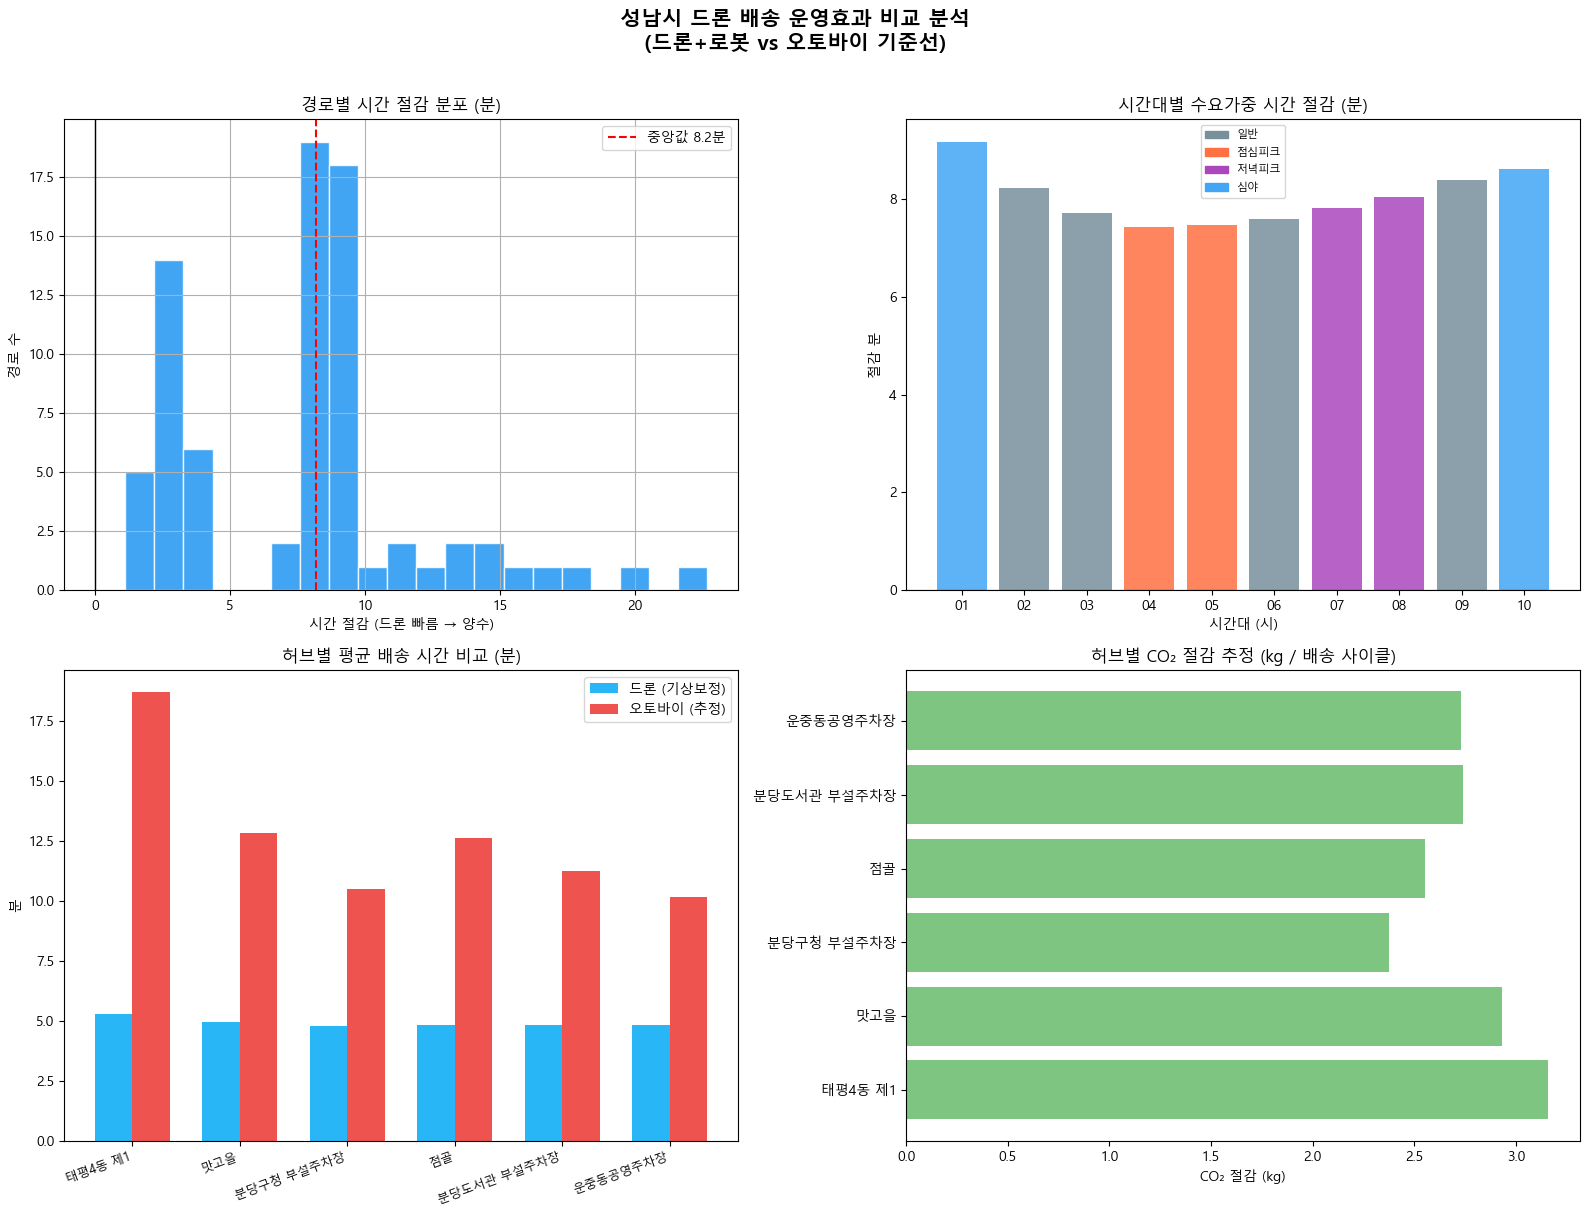

  Chart saved → C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_comparison_chart.png
  Map saved → C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_delivery_impact_map.html


In [15]:
# ── §16 시각화 ───────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
from folium.plugins import MarkerCluster

matplotlib.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    '성남시 드론 배송 운영효과 비교 분석\n(드론+로봇 vs 오토바이 기준선)',
    fontsize=15, fontweight='bold', y=1.01
)

# ── 16-a: Time-saving distribution
ax = axes[0, 0]
ts_valid = df['time_saving_min'].dropna()
ts_valid.hist(bins=20, ax=ax, color='#2196F3', edgecolor='white', alpha=0.85)
ax.axvline(ts_valid.median(), color='red', linestyle='--', linewidth=1.5,
           label=f'중앙값 {ts_valid.median():.1f}분')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('경로별 시간 절감 분포 (분)')
ax.set_xlabel('시간 절감 (드론 빠름 → 양수)')
ax.set_ylabel('경로 수')
ax.legend()

# ── 16-b: Hourly demand-weighted time saving
ax = axes[0, 1]
PERIOD_COLORS = {'일반': '#78909C', '점심피크': '#FF7043',
                 '저녁피크': '#AB47BC', '심야': '#42A5F5'}
hd_sorted = hourly_display.sort_values('hour_code')
for _, row in hd_sorted.iterrows():
    ax.bar(row['hour_code'], row['time_saving_min'],
           color=PERIOD_COLORS.get(row['period'], '#78909C'), alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('시간대별 수요가중 시간 절감 (분)')
ax.set_xlabel('시간대 (시)')
ax.set_ylabel('절감 분')
ax.legend(handles=[
    mpatches.Patch(color=c, label=l) for l, c in PERIOD_COLORS.items()
], fontsize=8)

# ── 16-c: Hub-level average delivery time comparison
ax = axes[1, 0]
x = range(len(hub_summary))
w = 0.35
ax.bar([i - w / 2 for i in x], hub_summary['avg_drone_time_min'],
       w, label='드론 (기상보정)', color='#29B6F6')
ax.bar([i + w / 2 for i in x], hub_summary['avg_moto_time_min'],
       w, label='오토바이 (추정)', color='#EF5350')
ax.set_xticks(list(x))
ax.set_xticklabels(hub_summary['assigned_lot_name'],
                   rotation=20, ha='right', fontsize=9)
ax.set_title('허브별 평균 배송 시간 비교 (분)')
ax.set_ylabel('분')
ax.legend()

# ── 16-d: CO2 saving by hub
ax = axes[1, 1]
ax.barh(hub_summary['assigned_lot_name'].astype(str),
        hub_summary['total_co2_saving_g'] / 1000,
        color='#66BB6A', alpha=0.85)
ax.set_title('허브별 CO\u2082 절감 추정 (kg / 배송 사이클)')
ax.set_xlabel('CO\u2082 절감 (kg)')

plt.tight_layout()
chart_path = OUT13 / 'nb13_comparison_chart.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Chart saved \u2192 {chart_path}')

# ── Folium interactive map
m = folium.Map(location=[37.43, 127.14], zoom_start=12,
               tiles='CartoDB positron')

hub_cluster = MarkerCluster(name='허브 (Hub)', show=True).add_to(m)
zone_cluster = MarkerCluster(name='배송 구역 (Delivery Zone)', show=True).add_to(m)

# Hub markers
for _, h in df_hubs.iterrows():
    if pd.notna(h['hub_lat']):
        folium.Marker(
            [h['hub_lat'], h['hub_lon']],
            popup=folium.Popup(f"<b>{h['lot_id']}</b>", max_width=200),
            icon=folium.Icon(color='blue', icon='home'),
        ).add_to(hub_cluster)

# Target zone markers coloured by time saving
for _, r in df.dropna(subset=['target_lat', 'target_lon']).iterrows():
    saving = r['time_saving_min']
    color  = 'green' if saving > 3 else ('orange' if saving > 0 else 'red')
    moto_t = f"{r['moto_time_est_min']:.1f}" if pd.notna(r['moto_time_est_min']) else 'N/A'
    drone_t = f"{r['drone_time_wx_adj_min']:.1f}" if pd.notna(r['drone_time_wx_adj_min']) else 'N/A'
    folium.CircleMarker(
        [r['target_lat'], r['target_lon']], radius=6,
        color=color, fill=True, fill_opacity=0.75,
        popup=folium.Popup(
            f"<b>{r.get('target_ADM_NM', '')}</b><br>"
            f"드론(기상보정): {drone_t}분<br>"
            f"오토바이: {moto_t}분<br>"
            f"절감: {saving:.1f}분",
            max_width=240
        ),
    ).add_to(zone_cluster)

folium.LayerControl().add_to(m)
map_path = OUT13 / 'nb13_delivery_impact_map.html'
m.save(str(map_path))
print(f'  Map saved \u2192 {map_path}')

In [16]:
# ── §17 결과 저장 및 요약 ────────────────────────────────────────────────
import json as _json

_route_cols = [
    'assigned_lot_id', 'assigned_lot_name',
    'target_h3_index', 'target_ADM_NM', 'target_GU_NM',
    'hub_lat', 'hub_lon', 'target_lat', 'target_lon', 'CSV_ADMI_CD',
    'Ds', 'delivery_zone',
    'straight_dist_m', 'drone_distance_m', 'road_dist_proxy_m', 'road_dist_used_m',
    'moto_time_est_min', 'moto_time_source', 'moto_time_fallback_min',
    'kosha_success', 'kosha_result_code', 'kosha_result_msg',
    'kosha_moto_time_min', 'kosha_moto_dist_m',
    'drone_time_min', 'drone_direct_eta_min', 'drone_time_wx_adj_min',
    'drone_robot_full_eta_min', 'drone_robot_full_wx_expected_eta_min',
    'robot_distance_m', 'robot_time_min_adjusted',
    'time_saving_min', 'time_saving_pct', 'speedup_ratio', 'drone_faster',
    'time_saving_robot_full_min', 'time_saving_robot_full_pct',
    'drone_robot_full_faster',
    'moto_co2_g', 'drone_co2_g', 'drone_robot_full_co2_g',
    'co2_saving_g', 'co2_saving_robot_full_g',
    'airspace_approval_required', 'drone_direct_feasible_strict',
    'robot_handoff_feasible', 'mean_slope_deg', 'route_mean_constraint_score',
    'in_baedal_zone', 'baedal_zone_id', 'baedal_zone_name',
]

route_path = OUT13 / 'nb13_route_comparison.csv'
route_path2 = OUT13 / 'nb13_delivery_impact_routes.csv'
df[[c for c in _route_cols if c in df.columns]].to_csv(route_path, index=False, encoding='utf-8-sig')
df[[c for c in _route_cols if c in df.columns]].to_csv(route_path2, index=False, encoding='utf-8-sig')
print(f'  Saved: {route_path}  ({len(df)} rows)')
print(f'  Saved: {route_path2}  ({len(df)} rows)')

hub_path = OUT13 / 'nb13_hub_summary.csv'
hub_path2 = OUT13 / 'nb13_delivery_impact_by_hub.csv'
hub_summary.to_csv(hub_path, index=False, encoding='utf-8-sig')
hub_summary.to_csv(hub_path2, index=False, encoding='utf-8-sig')
print(f'  Saved: {hub_path}  ({len(hub_summary)} rows)')

hourly_path = OUT13 / 'nb13_hourly_breakdown.csv'
hourly_path2 = OUT13 / 'nb13_delivery_impact_by_hour.csv'
hourly_display.to_csv(hourly_path, index=False, encoding='utf-8-sig')
hourly_display.to_csv(hourly_path2, index=False, encoding='utf-8-sig')
print(f'  Saved: {hourly_path}  ({len(hourly_display)} rows)')

district_path = OUT13 / 'nb13_district_summary.csv'
district_summary.to_csv(district_path, index=False, encoding='utf-8-sig')
print(f'  Saved: {district_path}  ({len(district_summary)} rows)')

summary_df = pd.DataFrame([
    {'metric': 'route_count', 'value': len(df)},
    {'metric': 'hub_count', 'value': df['assigned_lot_id'].nunique()},
    {'metric': 'kosha_success_count', 'value': int(df['kosha_success'].sum())},
    {'metric': 'kosha_success_rate_pct', 'value': float(df['kosha_success'].mean() * 100)},
    {'metric': 'fallback_count', 'value': int((df['moto_time_source'] == 'fallback_speed_model').sum())},
    {'metric': 'mean_motorcycle_eta_min', 'value': float(df['moto_time_est_min'].mean())},
    {'metric': 'mean_drone_direct_wx_eta_min', 'value': float(df['drone_time_wx_adj_min'].mean())},
    {'metric': 'mean_drone_robot_full_wx_eta_min', 'value': float(df['drone_robot_full_wx_expected_eta_min'].mean())},
    {'metric': 'median_direct_time_saving_min', 'value': float(df['time_saving_min'].median())},
    {'metric': 'median_robot_full_time_saving_min', 'value': float(df['time_saving_robot_full_min'].median())},
    {'metric': 'direct_routes_faster_pct', 'value': float(df['drone_faster'].mean() * 100)},
    {'metric': 'robot_full_routes_faster_pct', 'value': float(df['drone_robot_full_faster'].mean() * 100)},
    {'metric': 'total_direct_co2_saving_kg_per_cycle', 'value': float(df['co2_saving_g'].sum() / 1000)},
    {'metric': 'total_robot_full_co2_saving_kg_per_cycle', 'value': float(df['co2_saving_robot_full_g'].sum() / 1000)},
    {'metric': 'baedal_zone_route_share_pct', 'value': float(df['in_baedal_zone'].mean() * 100)},
    {'metric': 'P_drone_weather_available', 'value': P_DRONE_WX_AVAILABLE},
    {'metric': 'motorcycle_fallback_speed_kmh', 'value': MOTORCYCLE_AVG_SPEED},
])
summary_csv = OUT13 / 'nb13_delivery_impact_summary.csv'
summary_df.to_csv(summary_csv, index=False, encoding='utf-8-sig')

warnings_list = []
if int(df['kosha_success'].sum()) < len(df):
    warnings_list.append('Some routes used fallback motorcycle ETA because KOSHA did not return a usable time.')
if len(df_speed_seongnam) == 0:
    warnings_list.append('Gyeonggi speed API loaded no Seongnam keyword rows in fetched reference page; default motorcycle speed retained for fallback only.')
if (df['time_saving_robot_full_min'] < 0).any():
    warnings_list.append('Full robot ground-leg sensitivity is slower than motorcycle for some routes; use direct-drone scenario as primary NB13 impact.')

_n = len(df)
_dfn = int(df['drone_faster'].sum())
_report = {
    'notebook': 'NB13_delivery_impact_comparison',
    'run_date': pd.Timestamp.now().isoformat(),
    'n_routes_analyzed': _n,
    'n_hubs': int(df['assigned_lot_id'].nunique()),
    'P_drone_weather_available': P_DRONE_WX_AVAILABLE,
    'motorcycle_avg_speed_kmh': round(float(MOTORCYCLE_AVG_SPEED), 2),
    'kosha_api_success_count': int(df['kosha_success'].sum()),
    'kosha_api_success_rate_pct': round(float(df['kosha_success'].mean() * 100), 2),
    'motorcycle_fallback_count': int((df['moto_time_source'] == 'fallback_speed_model').sum()),
    'gg_speed_rows_loaded': int(len(df_speed)),
    'gg_speed_seongnam_keyword_rows': int(len(df_speed_seongnam)),
    'traffic_speed_scope': traffic_speed_scope,
    'pct_routes_drone_faster': round(_dfn / _n * 100, 2) if _n else 0,
    'pct_routes_robot_full_faster': round(float(df['drone_robot_full_faster'].mean() * 100), 2),
    'median_time_saving_min': round(float(df['time_saving_min'].median()), 3),
    'median_robot_full_time_saving_min': round(float(df['time_saving_robot_full_min'].median()), 3),
    'mean_speedup_ratio': round(float(df['speedup_ratio'].mean()), 4),
    'total_co2_saving_kg': round(float(df['co2_saving_g'].sum() / 1000), 3),
    'total_robot_full_co2_saving_kg': round(float(df['co2_saving_robot_full_g'].sum() / 1000), 3),
    'pct_zones_in_baedal_cluster': round(float(df['in_baedal_zone'].mean() * 100), 2),
    'lunch_demand_pct': round(lunch_demand, 2),
    'dinner_demand_pct': round(dinner_demand, 2),
    'warnings': warnings_list,
    'notes': [
        'KOSHA API provides official safe delivery-time guidance, not observed platform trip logs.',
        'Primary scenario is approval-required direct drone service; full robot ground leg is sensitivity.',
        '관제권 is treated as approval/review in the primary scenario, not hard exclusion.'
    ],
    'outputs': {
        'route_comparison': str(route_path),
        'route_comparison_stable': str(route_path2),
        'hub_summary': str(hub_path),
        'hub_summary_stable': str(hub_path2),
        'hourly_breakdown': str(hourly_path),
        'hourly_breakdown_stable': str(hourly_path2),
        'district_summary': str(district_path),
        'summary_csv': str(summary_csv),
        'kosha_cache': str(KOSHA_CACHE),
        'gg_speed_ref': str(GG_CACHE),
        'map': str(map_path),
        'chart': str(chart_path),
    }
}

summary_path = OUT13 / 'nb13_summary_report.json'
diagnostics_path = OUT13 / 'nb13_delivery_impact_diagnostics.json'
for _p in [summary_path, diagnostics_path]:
    with open(_p, 'w', encoding='utf-8') as _f:
        _json.dump(_report, _f, ensure_ascii=False, indent=2)
print(f'  Saved: {summary_path}')
print(f'  Saved: {diagnostics_path}')

print('\n' + '=' * 65)
print('  NB13 결과 요약')
print('=' * 65)
print(f'  분석 경로 수             : {_n}개')
print(f'  KOSHA 성공률             : {_report["kosha_api_success_rate_pct"]:.1f}%')
print(f'  직접 드론이 빠른 경로 비율: {_report["pct_routes_drone_faster"]:.1f}%')
print(f'  직접 드론 중앙값 시간절감 : {_report["median_time_saving_min"]:.1f}분')
print(f'  로봇 전체구간 민감도 중앙값: {_report["median_robot_full_time_saving_min"]:.1f}분')
print(f'  직접 드론 CO₂ 절감 추정  : {_report["total_co2_saving_kg"]:.2f} kg/사이클')
print(f'  배달상권 커버 비율       : {_report["pct_zones_in_baedal_cluster"]:.1f}%')
print('=' * 65)

print('\nNB13 · FINAL VALIDATION')
checks = []
def _chk(label, ok):
    checks.append(bool(ok))
    print(f'  {"✓" if ok else "✗"} {label}')

_chk('assignments loaded == 67', len(df_assign) == 67)
_chk('final hubs loaded == 5', len(df_hubs) == 5)
_chk('route table rows == 67', len(df) == 67)
_chk('motorcycle ETA source coverage == 67', df['moto_time_est_min'].notna().sum() == 67)
_chk('KOSHA successes + fallback rows == 67',
     int(df['kosha_success'].sum()) + int((df['moto_time_source'] == 'fallback_speed_model').sum()) == 67)
_chk('motorcycle ETA non-null', df['moto_time_est_min'].notna().all())
_chk('drone direct weather ETA non-null', df['drone_time_wx_adj_min'].notna().all())
_chk('full robot sensitivity ETA non-null', df['drone_robot_full_wx_expected_eta_min'].notna().all())
_chk('배달상권 Seongnam polygons loaded', gdf_baedal is not None and len(gdf_baedal) >= 1)
_chk('chart exists', chart_path.exists())
_chk('route CSV exists', route_path.exists() and route_path2.exists())
_chk('summary CSV exists', summary_csv.exists())
_chk('diagnostics JSON exists', diagnostics_path.exists())

if all(checks):
    print('NB13 VALIDATION PASSED — ready for NB14')
else:
    print('NB13 VALIDATION FAILED — check diagnostics above')


  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_route_comparison.csv  (77 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_delivery_impact_routes.csv  (77 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_hub_summary.csv  (6 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_hourly_breakdown.csv  (10 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_district_summary.csv  (32 rows)
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_summary_report.json
  Saved: C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam_reset\processed\nb13_delivery_impact_diagnostics.json

  NB13 결과 요약
  분석 경로 수             : 77개
  KOSHA 성공률             : 67.5%
  직접 드론이 빠른 경로 비율: 100.0%
  직접 드론 중앙값 시간절감 : 8.2분
  로봇 전체구간 민감도 중앙값: -13.1분
  직접 드론 CO₂ 절감 추정  : 16.48 kg/사이클
  배달상권 커버 비율       : 2.6%

NB13 · FINAL VALIDATION
  ✗ as